<a href="https://colab.research.google.com/github/FerGuzman65/APPrentas2/blob/main/A2_Data_Quality_Preparacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

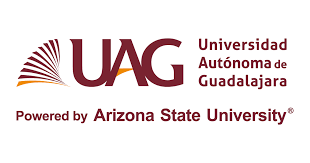



Manuel Fernando Guzman Arias
4948560
UAG P1
https://colab.research.google.com/github/ENRIKO-18/DataMining/blob/main/A2_Data_Quality_Preparacion.ipynb


# Minería de Datos
## Actividad: Calidad y Preparación de Datos

**Entorno:** Google Colab + Pandas  
**Archivo:** `estudiantes_rendimiento_100_registros.csv`

---
## Objetivo general
Analizar la calidad de un conjunto de datos utilizando métricas de Data Quality y posteriormente aplicar técnicas de preparación de datos para su uso en minería de datos.

## Parte 1 – Carga y exploración inicial de los datos
1. Cargue el archivo CSV usando Pandas.
2. Muestre las primeras filas del dataset.
3. Explore la estructura general de los datos (`info`, `describe`,  `shape`).

In [2]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('estudiantes_rendimiento_100_registros.csv')
df.head()

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus
0,1,19.0,X,Medicina,4,-10,52,2025-04-30,NaN,Activo
1,2,NaN,M,Ingeniería,2,-10,258,2024-11-28,alumno2@universidad.mx,Activo
2,3,NaN,M,Arquitectura,5,-10,216,2023-06-11,alumno3universidad.mx,Activo
3,4,NaN,M,Ingeniería,7,110,176,2024-12-02,alumno4universidad.mx,Activo
4,5,25.0,F,Ingeniería,9,110,295,2022-08-12,NaN,Activo


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Parte 2 – Análisis de Calidad de Datos
Evalúe las siguientes dimensiones. Para cada una:
- Explique brevemente qué significa.
- Muestre el análisis en código.
- Interprete los resultados.

### 2.1 Completeness (Completitud)
- Muestre el total de valores faltantes (isnull) por columna.
- Muestre el total de valores faltantes (isnull) por registro.

In [7]:
# Completeness-columna
# --- Análisis de Completitud por columna ---
print("Valores faltantes por columna")
faltantes_por_columna = df.isnull().sum()
print(faltantes_por_columna)

=== Valores faltantes por columna ===
id_estudiante          0
edad                  53
sexo                   0
carrera                0
semestre               0
promedio               0
creditos_aprobados     0
fecha_registro         0
correo                31
estatus                0
dtype: int64


In [ ]:
# Completeness-registro
#
print("=== Valores faltantes por registro (fila) ===")
faltantes_por_fila = df.isnull().sum(axis=1)

filas_incompletas = faltantes_por_fila[faltantes_por_fila > 0]

if not filas_incompletas.empty:
    print("Índice del registro y cantidad de valores nulos:")
    print(filas_incompletas)
    print(f"\nTotal de registros (estudiantes) incompletos: {len(filas_incompletas)}")
else:


La completitud evalúa datos nulos en el dataser. Los resultados indican que el dataset está incompleto, con 53 valores nulos en la columna edad y 31 en la columna correo, mientras que el resto de las variables estan llenas.

Analisis df.isnull() escanea la base de datos e identifica las celdas vacías (nulas). Al agregar .sum() se suma el total de esos valores faltantes de arriba hacia abajo, mostrándolos por columna. Al usar sum(axis=1), la suma cambia de dirección y se hace de izquierda a derecha, calculando cuántos datos le faltan a cada fila (registro). Finalmente, la variable filas_incompletas usa la condición > 0 para filtrar y mostrar en pantalla únicamente a los estudiantes que tienen al menos un dato faltante.

### 2.2 Uniqueness (Unicidad)
Analice duplicados en `id_estudiante` y correos electrónicos (correo') y muestra un conteo de cuantos duplicados totales hay en estas dos columnas.

In [9]:
# Uniqueness
ssss = df['id_estudiante'].duplicated().sum()
duplicados_correo = df['correo'].duplicated().sum()

print(f"Duplicados en id_estudiante: {ssss}")
print(f"Duplicados en correo: {duplicados_correo}")
print(f"Total de duplicados en ambas columnas: {ssss + duplicados_correo}")

Duplicados en id_estudiante: 1
Duplicados en correo: 30
Total de duplicados en ambas columnas: 31


### 2.3 Validity (Validez)
Implemente dos reglas de validación a alguna de las siguientes variables: edad, promedio, correo, sexo.
Como salida miestra aquellos registros que no cumplan con alguna de las dos reglas propuestas ("|").

Describe brevemente en que consistieron las reglas.

In [11]:
# Validity -Regla 1
#que la edad de los estudiantes
#se encuentre dentro de un rango
# de 17-100
regla1_invalida = (df['edad'] < 17) | (df['edad'] > 100)

In [12]:
# Validity - Regla 2
#Se validó que el promedio de calificaciones esté
#entre 0-100
regla2_invalida = (df['promedio'] < 0) | (df['promedio'] > 100)

df[regla1_invalida | regla2_invalida]

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus
0,1,19.0,X,Medicina,4,-10,52,2025-04-30,NaN,Activo
1,2,NaN,M,Ingeniería,2,-10,258,2024-11-28,alumno2@universidad.mx,Activo
2,3,NaN,M,Arquitectura,5,-10,216,2023-06-11,alumno3universidad.mx,Activo
3,4,NaN,M,Ingeniería,7,110,176,2024-12-02,alumno4universidad.mx,Activo
4,5,25.0,F,Ingeniería,9,110,295,2022-08-12,NaN,Activo
...,...,...,...,...,...,...,...,...,...,...
94,95,24.0,M,Arquitectura,3,-10,40,2024-12-14,alumno95universidad.mx,Activo
95,96,25.0,M,Arquitectura,5,110,4,2024-02-22,alumno96universidad.mx,Activo
96,97,NaN,F,Medicina,7,110,233,2023-03-25,alumno97@universidad.mx,Baja
97,98,25.0,M,Arquitectura,6,110,151,2021-08-28,NaN,Baja


### 2.4 Timeliness
 Analice si las fechas de registro ("fecha_registro")son razonables respecto a la fecha actual.

In [13]:
# Conversión a formato fecha
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])

import pandas as pd
df[df['fecha_registro'] > pd.Timestamp.now()]

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus


### 2.5 Accuracy (Exactitud)
Identifique valores improbables o poco realistas en 'créditos_aprobados' y en la columna 'edad', considerando son estudiantes de universidad (mayores a 16 años) y cuyos créditos no superan los 300. Muestra como salida aquellos registros que cumplen con una u otra condición ("|").

In [14]:
# Accuracy
df[(df['edad'] <= 16) | (df['creditos_aprobados'] > 300)]

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus
6,7,NaN,F,Derecho,5,89,311,2025-02-04,alumno7@universidad.mx,Activo
10,11,19.0,M,Derecho,3,999,305,2021-11-22,alumno11universidad.mx,Baja
13,14,22.0,M,Medicina,3,69,306,2023-05-09,alumno14universidad.mx,Activo
41,42,26.0,M,Arquitectura,7,-10,315,2024-09-22,alumno42universidad.mx,Baja
44,45,21.0,M,Ingeniería,1,999,312,2021-12-11,alumno45universidad.mx,Baja
76,77,NaN,M,Ingeniería,1,110,304,2024-09-22,alumno77universidad.mx,Baja
98,99,22.0,X,Ingeniería,8,-10,310,2023-07-06,alumno99@universidad.mx,Activo


### 2.6 Consistency (Consistencia)
Reviar consistencia entre créditos y estatus sabiendo que un estatus 'Baja' debe presentarse cuando el promedio sea menor a 70. Mostrar como salida aquellos registros que no cumplen la condición.

In [29]:
# Consistency
df[((df['promedio'] < 70) & (df['estatus'] != 'Baja')) | ((df['promedio'] >= 70) & (df['estatus'] == 'Baja'))]

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus
0,1,19.0,X,Medicina,4,-10,52,2025-04-30,NaN,Activo
1,2,NaN,M,Ingeniería,2,-10,258,2024-11-28,alumno2@universidad.mx,Activo
2,3,NaN,M,Arquitectura,5,-10,216,2023-06-11,alumno3universidad.mx,Activo
5,6,18.0,F,Ingeniería,4,999,142,2024-01-29,NaN,Baja
7,8,NaN,F,Medicina,9,110,28,2022-10-27,alumno8@universidad.mx,Baja
9,10,22.0,M,Medicina,7,999,185,2022-10-07,alumno10@universidad.mx,Baja
10,11,19.0,M,Derecho,3,999,305,2021-11-22,alumno11universidad.mx,Baja
13,14,22.0,M,Medicina,3,69,306,2023-05-09,alumno14universidad.mx,Activo
14,15,NaN,F,Derecho,1,30,43,2024-04-05,alumno15@universidad.mx,Activo
17,18,23.0,X,Derecho,4,0,30,2022-10-26,alumno18@universidad.mx,Activo


## Parte 3 – Conclusiones de Calidad de Datos
Responda:
- ¿Cuál fue la dimensión con más problemas?

el de completeness ya que tuvo 53 + 31 errores en total(nulos)
- ¿El dataset es apto para minería de datos en su estado actual?No ya que tiene muchos valores fuera de lugar y hasta muchos nulos


---
## Parte 4 – Preparación de Datos (Tarea 2)
A partir del diagnóstico previo, realice las siguientes etapas:

### 4.1 Limpieza de datos


4.1.1 Eliminación de duplicados.



In [16]:
# Elimina los duplicados de la tabla y guar el df en una variable nueva (df_clean)
df_clean = df.drop_duplicates()

4.1.2 Tratamiento de valores faltantes

In [ ]:
#Cuenta cuantos datos nulos existen en la columna "edad"
df_clean['edad'].isnull().sum()

In [17]:
#llena los valor nulos de la columna "edad" (fillna) con la mediana de las edades existentes
df_clean['edad'] = df_clean['edad'].fillna(df_clean['edad'].median())


Antes de borrar datos en la columna (ej. 'promedio'), siempre es mejor "verlos". Para identificar valores atípicos (o outliers), la mejor herramienta es el Boxplot (Diagrama de Caja).

Para crear este gráfico en Python, usaremos las librerías seaborn y matplotlib. Aquí tienes el código que necesitas:

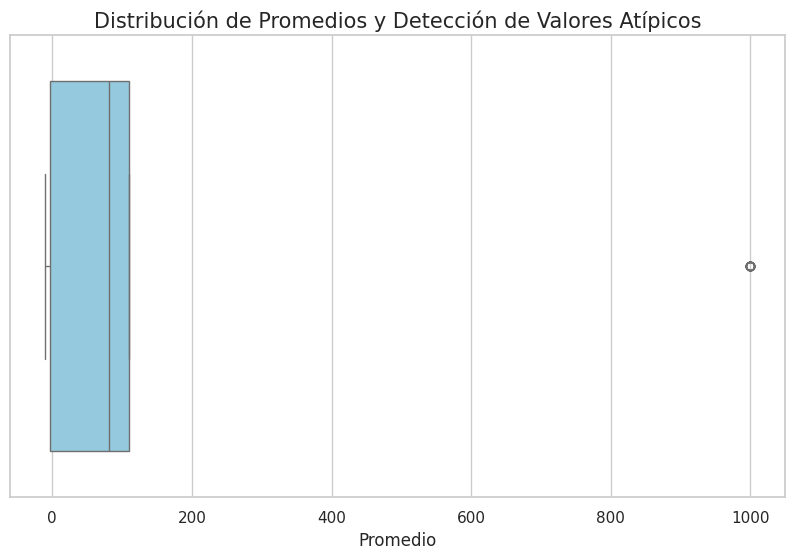

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_clean['promedio'], color='skyblue')

plt.title('Distribución ', fontsize=15)
plt.xlabel('Promedio', fontsize=12)

plt.show()

**4.1.3 Limpieza por rango**

Filtrado de datos para quedarase con los registros que cumplan con una condición.

In [20]:
# Mantén únicamente las filas donde el valor de la columna 'promedio' esté entre 0 y 100 (inclusive)".
df_clean = df_clean[(df_clean['promedio'] >= 0) & (df_clean['promedio'] <= 100)]
df_clean.head()

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus
6,7,24.0,F,Derecho,5,89,311,2025-02-04,alumno7@universidad.mx,Activo
11,12,24.0,X,Medicina,9,1,274,2023-01-12,NaN,Baja
13,14,22.0,M,Medicina,3,69,306,2023-05-09,alumno14universidad.mx,Activo
14,15,24.0,F,Derecho,1,30,43,2024-04-05,alumno15@universidad.mx,Activo
17,18,23.0,X,Derecho,4,0,30,2022-10-26,alumno18@universidad.mx,Activo


Ahora que hemos eliminado aquellos datos que salen de la condición, vuelve a generar la gráfica de caja para ver como están distribuidos tus datos.


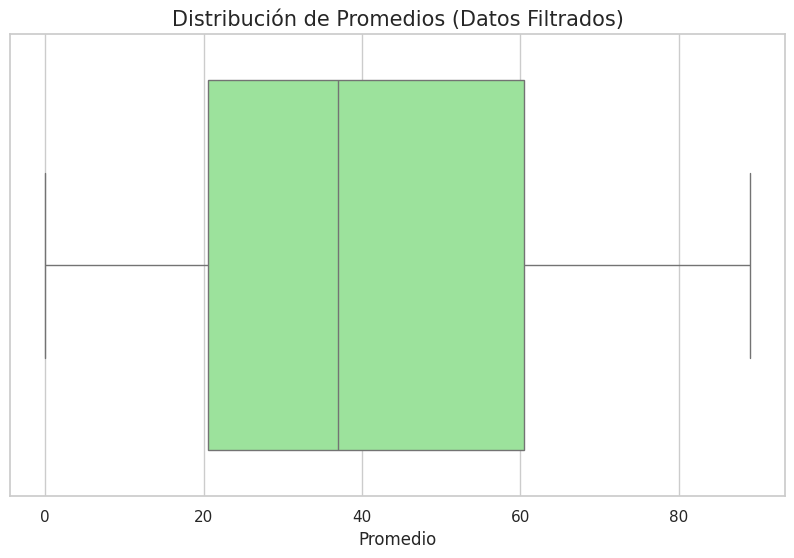

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos el gráfico de caja para la columna 'promedio' con los datos filtrados
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_clean['promedio'], color='lightgreen')

# Añadimos títulos
plt.title('Distribución de Promedios (Datos Filtrados)', fontsize=15)
plt.xlabel('Promedio', fontsize=12)

plt.show()

¿Vez alguna diferencia antes y despues de la limpieza en 'promedio'?

SI que los outliers son eliminados dejando en si una grafica mas estetica y verdadera, usable




### 4.2 Transformación
- Conversión de tipos de datos.
- Codificación de variables categóricas.
- Normalización o estandarización si aplica.

In [22]:
# Imprime el tipode dato de tus columnas en df_clean. ¿Que tipo de dato es 'sexo'?
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 6 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_estudiante       27 non-null     int64         
 1   edad                27 non-null     float64       
 2   sexo                27 non-null     object        
 3   carrera             27 non-null     object        
 4   semestre            27 non-null     int64         
 5   promedio            27 non-null     int64         
 6   creditos_aprobados  27 non-null     int64         
 7   fecha_registro      27 non-null     datetime64[ns]
 8   correo              20 non-null     object        
 9   estatus             27 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 2.3+ KB


Dado que queremos trabajar con valores numéricos en 'sexo', necesitamos convertirlos.

".map({...})": Es la función que hace la conversión. Utiliza un diccionario {clave: valor} donde la "clave" es lo que buscas y el "valor" es el resultado deseado.

In [24]:
#De la columna de 'sexo' convierte aquellos valores 'M' a 0´s y 'F' a 1´s.
df_clean['sexo'] = df_clean['sexo'].map({'M': 0, 'F': 1})
df_clean.head()

,id_estudiante,edad,sexo,carrera,semestre,promedio,creditos_aprobados,fecha_registro,correo,estatus
6,7,24.0,1.0,Derecho,5,89,311,2025-02-04,alumno7@universidad.mx,Activo
11,12,24.0,NaN,Medicina,9,1,274,2023-01-12,NaN,Baja
13,14,22.0,0.0,Medicina,3,69,306,2023-05-09,alumno14universidad.mx,Activo
14,15,24.0,1.0,Derecho,1,30,43,2024-04-05,alumno15@universidad.mx,Activo
17,18,23.0,NaN,Derecho,4,0,30,2022-10-26,alumno18@universidad.mx,Activo


**One-Hot Encoding** (o creación de variables variables "dummy"): Es el siguiente nivel de transformación después del simple mapeo.

Transforma columnas que tienen categorías de texto (como nombres de carreras) en múltiples columnas nuevas de unos (1) y ceros (0).

In [25]:
#Implementa ONE-HOT ENCODING (.get_dummies) para las columnas 'carrera' y 'estatus'.
df_clean = pd.get_dummies(df_clean, columns=['carrera', 'estatus'])
df_clean.head()

,id_estudiante,edad,sexo,semestre,promedio,creditos_aprobados,fecha_registro,correo,carrera_Arquitectura,carrera_Derecho,carrera_Ingeniería,carrera_Medicina,estatus_Activo,estatus_Baja
6,7,24.0,1.0,5,89,311,2025-02-04,alumno7@universidad.mx,False,True,False,False,True,False
11,12,24.0,NaN,9,1,274,2023-01-12,NaN,False,False,False,True,False,True
13,14,22.0,0.0,3,69,306,2023-05-09,alumno14universidad.mx,False,False,False,True,True,False
14,15,24.0,1.0,1,30,43,2024-04-05,alumno15@universidad.mx,False,True,False,False,True,False
17,18,23.0,NaN,4,0,30,2022-10-26,alumno18@universidad.mx,False,True,False,False,True,False


### 4.3 Reducción
Eliminda de tu dataframe las columnas 'correo' & 'fecha_registro'.
Muestras tu dataframe y su tamaño final.

In [26]:
df_clean = df_clean.drop(columns=['correo', 'fecha_registro'])

display(df_clean.head())
print("\nTamaño final del dataset (filas, columnas):", df_clean.shape)

,id_estudiante,edad,sexo,semestre,promedio,creditos_aprobados,carrera_Arquitectura,carrera_Derecho,carrera_Ingeniería,carrera_Medicina,estatus_Activo,estatus_Baja
6,7,24.0,1.0,5,89,311,False,True,False,False,True,False
11,12,24.0,NaN,9,1,274,False,False,False,True,False,True
13,14,22.0,0.0,3,69,306,False,False,False,True,True,False
14,15,24.0,1.0,1,30,43,False,True,False,False,True,False
17,18,23.0,NaN,4,0,30,False,True,False,False,True,False



Tamaño final del dataset (filas, columnas): (27, 12)


### 4.4 Partición de los datos

Este es el paso previo al análisis con cualquier modelo de Machine Learning.

El datset se tiene que dividir en dos grupos distintos para poder evaluar si el modelo realmente está aprendiendo o si solo está memorizando.


In [ ]:
from sklearn.model_selection import train_test_split  #importamos la función 'train_test_split de SKLEARN

In [28]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df_clean, test_size=0.3, random_state=42)

print(f"Registros para entrenamiento: {len(train)}")
print(f"Registros para prueba: {len(test)}")

Registros para entrenamiento: 18
Registros para prueba: 9


## Reflexión final
Explique cómo la preparación de datos mejora la calidad y confiabilidad para aplicar técnicas de minería de datos.

La preparacion de los datos mejora la calidad y la confiabilidad del analisis de tranformar registros en este caso malos con mucho ruido o valores faltantes  usando tecnicas para integrar informacion semanticamente correcta , usando tambien la particion de dataset para generar patrones en la toma de desiciones, lograr tener informacion mediante los datos que se usable y correcta
LINK
https://colab.research.google.com/github/ENRIKO-18/DataMining/blob/main/A2_Data_Quality_Preparacion.ipynb
